# Exercise 4: Bonus Task

Welcome to the fourth exercise of **Generative AI** from the research group **Visual Computing and Artificial Intelligence (VCAI)**!

In this notebook, a VAE is created and trained based on ChestMNIST from MedMNIST (https://medmnist.com/). It is mandatory to use **PyTorch**.  
**What we expect:**
- Data:
  - Use code to load the dataset
  - Analyze the dataset
  - Perform preprocessing steps if necessary
- Model:
  - Create a VAE
- Training:
  - Suitable loss functions
  - Train VAE
  - Visualize results
- Generation and visualization of synthetic samples



**Note:**  
Please only insert your code in the spaces provided. If absolutely necessary, additional cells can also be created. The basic structure and clarity should be maintained.

## Exercise Group Information
- Group Number: FILL IN YOUR GROUP NUMBER
- Group Members: FILL IN THE NAMES OF ALL GROUP MEMBERS

## Table of Contents

- [1. Packages](#1)
  - [1.1 Import Packages](#1-1)
  - [1.2 GPU Usage](#1-2)
- [2. Data](#2)
  - [2.1 Load Dataset and apply necessary Preprocessing](#2-1) 
  - [2.2 Analyze the Dataset](#2-2)
  - [2.3 Preprocessing (if necessary)](#2-3)
- [3. Model](#3)
  - [3.1 Implement the VAE](#3-1) 
- [4. Training](#4)
  - [4.1 Define the Loss Function](#4-1) 
  - [4.2 Train the VAE](#4-2)
- [5. Generation](#5)
  - [5.1 Generate synthetic Samples](#5-1)


<a name="1"></a>
## 1. Packages

<a name="1-1"></a>
### 1.1 Import Packages
Please import all required packages, dependencies, and custom utility functions.

In [2]:
### START YOUR CODE HERE ###

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

try:
    import medmnist
    from medmnist import ChestMNIST
except ImportError as e:
    raise ImportError("Please install MedMNIST first: pip install medmnist") from e

# Make results more reproducible
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

### END OF YOUR CODE ###


<a name="1-2"></a>
### 1.2 GPU Usage
In order to speed up the training process, it is recommended to use the GPU.

In [3]:
# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<a name="2"></a>
## 2. Data

<a name="2-1"></a>
### 2.1 Load Dataset and apply necessary Preprocessing
Load the ChestMNIST dataset in a suitable format. Justify whether pre-processing steps are necessary and implement them (if none are necessary, this should be clear from the discussion). 

For this task, the ChestMNIST images are already resized to 28×28 pixels and are grayscale medical X-ray images. A Variational Autoencoder (VAE) needs numerical tensor input, so the main preprocessing step is converting each image to a PyTorch tensor. `transforms.ToTensor()` also scales pixel values from 0–255 to the range 0–1, which is suitable because the decoder uses a sigmoid output and the reconstruction loss uses binary cross entropy. No heavy augmentation is used because the goal is to learn the image distribution and generate/reconstruct samples, not to train a classifier.


In [4]:
### START YOUR CODE HERE ###

# Transform images to tensors in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load ChestMNIST train/validation/test splits
train_dataset = ChestMNIST(split='train', transform=transform, download=True)
val_dataset = ChestMNIST(split='val', transform=transform, download=True)
test_dataset = ChestMNIST(split='test', transform=transform, download=True)

# DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Label shape: {train_dataset[0][1].shape}")

### END OF YOUR CODE ###


100.0%


Train samples: 78468
Validation samples: 11219
Test samples: 22433
Image shape: torch.Size([1, 28, 28])
Label shape: (14,)


<a name="2-2"></a>
### 2.2 Analyze the Dataset
Display some samples from the dataset. You can also visualize other information if you want.

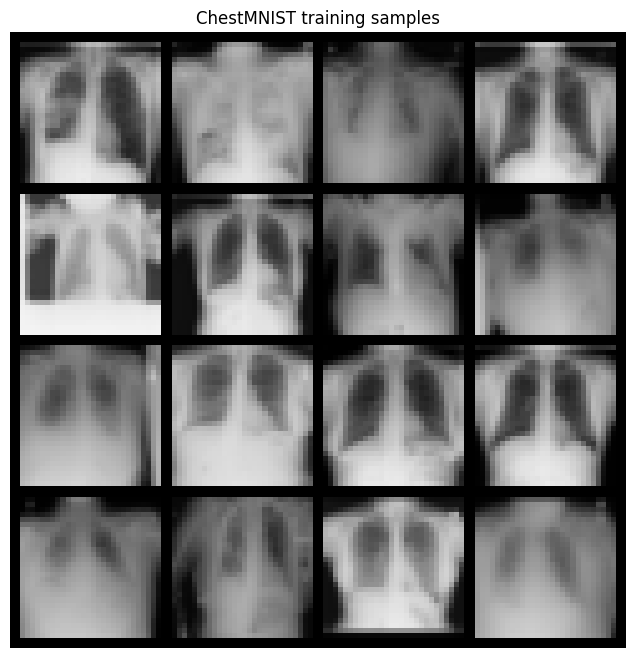

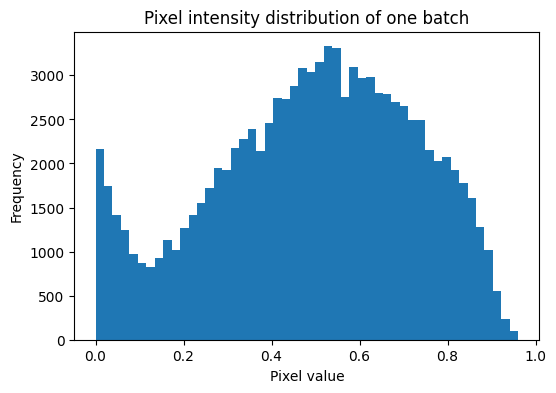

Batch image tensor shape: torch.Size([128, 1, 28, 28])
Minimum pixel value: 0.0000
Maximum pixel value: 0.9608
Mean pixel value: 0.4930


In [5]:
### START YOUR CODE HERE ###

# Display sample images from the training dataset
images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 8))
grid = make_grid(images[:16], nrow=4, padding=2)
plt.imshow(grid.permute(1, 2, 0), cmap='gray')
plt.title('ChestMNIST training samples')
plt.axis('off')
plt.show()

# Basic pixel-value analysis
all_pixels = images.view(-1).numpy()
plt.figure(figsize=(6, 4))
plt.hist(all_pixels, bins=50)
plt.title('Pixel intensity distribution of one batch')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.show()

print(f"Batch image tensor shape: {images.shape}")
print(f"Minimum pixel value: {images.min().item():.4f}")
print(f"Maximum pixel value: {images.max().item():.4f}")
print(f"Mean pixel value: {images.mean().item():.4f}")

### END OF YOUR CODE ###


<a name="3"></a>
## 3. Model

<a name="3-1"></a>
### 3.1 Implement the VAE
Implement a VAE suitable for the given data set. The predefined structure should be retained.

In [6]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# Define the VAE model
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.input_dim = 28 * 28
        self.hidden_dim = 400
        self.latent_dim = 32

        # Encoder
        self.fc1 = nn.Linear(self.input_dim, self.hidden_dim)
        self.fc_mu = nn.Linear(self.hidden_dim, self.latent_dim)
        self.fc_logvar = nn.Linear(self.hidden_dim, self.latent_dim)

        # Decoder
        self.fc2 = nn.Linear(self.latent_dim, self.hidden_dim)
        self.fc3 = nn.Linear(self.hidden_dim, self.input_dim)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        out = torch.sigmoid(self.fc3(h))
        return out.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar
    

### END OF YOUR CODE ###


<a name="4"></a>
## 4. Training

<a name="4-1"></a>
### 4.1 Define the Loss Function
Define the loss function for the training of the VAE. 


In [7]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# Define loss function
def loss_function(recon_x, x, mu, logvar):
    reconstruction_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss + kl_divergence

### END OF YOUR CODE ###


<a name="4-2"></a>
### 4.2 Train the VAE
Complete the VAE training function. Use the previously defined loss and also print the loss every epoch.

In [8]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# Training the VAE model
def train_vae(model, train_loader, num_epochs=10):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(num_epochs):
        train_loss = 0.0
        
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(data)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            
            train_loss += loss.item()
            optimizer.step()
        
        avg_loss = train_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

### END OF YOUR CODE ###


In [9]:
# Train the VAE model
model = VAE().to(device)
train_vae(model, train_loader)

Epoch [1/10], Loss: 480.4426
Epoch [2/10], Loss: 470.2855
Epoch [3/10], Loss: 468.6041
Epoch [4/10], Loss: 467.9386
Epoch [5/10], Loss: 467.4509
Epoch [6/10], Loss: 467.1098
Epoch [7/10], Loss: 466.7949
Epoch [8/10], Loss: 466.6726
Epoch [9/10], Loss: 466.5159
Epoch [10/10], Loss: 466.4547


Complete the function to show the reconstructed outputs of given inputs.

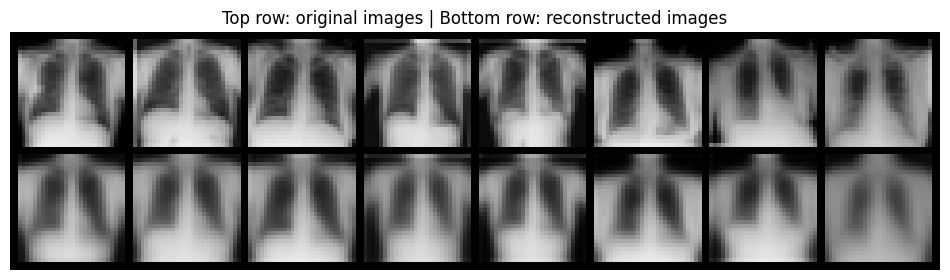

In [10]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# Display reconstruction samples side by side
def display_reconstruction():
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader))
        data = data[:8].to(device)
        recon, _, _ = model(data)
        
        comparison = torch.cat([data.cpu(), recon.cpu()])
        grid = make_grid(comparison, nrow=8, padding=2)
        
        plt.figure(figsize=(12, 4))
        plt.imshow(grid.permute(1, 2, 0), cmap='gray')
        plt.title('Top row: original images | Bottom row: reconstructed images')
        plt.axis('off')
        plt.show()

display_reconstruction()

### END OF YOUR CODE ###


<a name="5"></a>
## 5. Generation

<a name="5-1"></a>
### 5.1 Generate synthetic Samples
Generate synthetic samples by using random noise and the decoder. Plot the examples and discuss the results.

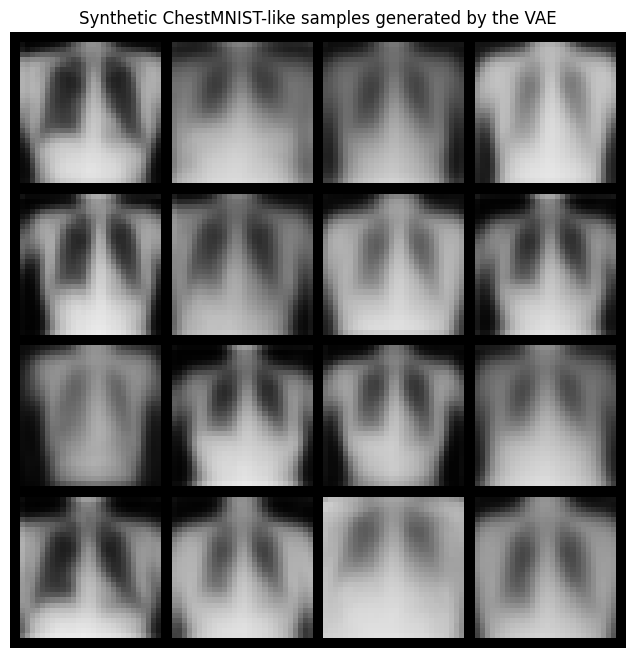

In [11]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# Generate and display images produced by the decoder from random noise
def display_generated():
    model.eval()
    with torch.no_grad():
        z = torch.randn(16, model.latent_dim).to(device)
        generated = model.decode(z).cpu()
        
        grid = make_grid(generated, nrow=4, padding=2)
        plt.figure(figsize=(8, 8))
        plt.imshow(grid.permute(1, 2, 0), cmap='gray')
        plt.title('Synthetic ChestMNIST-like samples generated by the VAE')
        plt.axis('off')
        plt.show()

display_generated()


### END OF YOUR CODE ###


The generated samples are produced by sampling random latent vectors from a standard normal distribution and passing them through the decoder. After training, the VAE should learn the general structure of ChestMNIST images, so the generated images should look similar to low-resolution chest X-ray samples. Because the images are only 28×28 pixels and the model is a simple fully connected VAE, the synthetic samples may look blurry. This is expected for a basic VAE because the reconstruction loss encourages smooth average-looking outputs. A deeper convolutional VAE could produce sharper and more realistic samples.


## Congratulations

You've finished the bonus task of the fourth exercise.